In [3]:
import pandas as pd

orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
df = orders.merge(items, on='order_id')
df = df.merge(customers, on='customer_id')

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [6]:
df['revenue'] = df['price'] + df['freight_value']

df['revenue'].sum()

np.float64(15843553.24)

In [7]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

df.groupby('month')['revenue'].sum()

month
2016-09        354.75
2016-10      56808.84
2016-12         19.62
2017-01     137188.49
2017-02     286280.62
2017-03     432048.59
2017-04     412422.24
2017-05     586190.95
2017-06     502963.04
2017-07     584971.62
2017-08     668204.60
2017-09     720398.91
2017-10     769312.37
2017-11    1179143.77
2017-12     863547.23
2018-01    1107301.89
2018-02     986908.96
2018-03    1155126.82
2018-04    1159698.04
2018-05    1149781.82
2018-06    1022677.11
2018-07    1058728.03
2018-08    1003308.47
2018-09        166.46
Freq: M, Name: revenue, dtype: float64

In [8]:
monthly_rev = df.groupby('month')['revenue'].sum().reset_index()

monthly_rev

,month,revenue
0,2016-09,354.75
1,2016-10,56808.84
2,2016-12,19.62
3,2017-01,137188.49
4,2017-02,286280.62
5,2017-03,432048.59
6,2017-04,412422.24
7,2017-05,586190.95
8,2017-06,502963.04
9,2017-07,584971.62


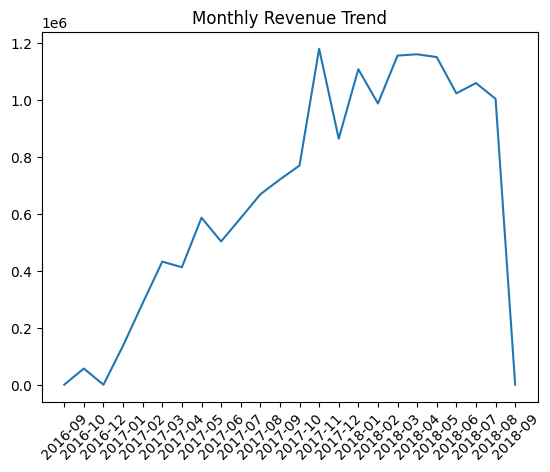

In [10]:
import matplotlib.pyplot as plt

monthly_rev['month'] = monthly_rev['month'].astype(str)

plt.plot(monthly_rev['month'], monthly_rev['revenue'])
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.show()

In [12]:
orders_monthly = df.groupby('month')['order_id'].nunique().reset_index()

orders_monthly

,month,order_id
0,2016-09,3
1,2016-10,308
2,2016-12,1
3,2017-01,789
4,2017-02,1733
5,2017-03,2641
6,2017-04,2391
7,2017-05,3660
8,2017-06,3217
9,2017-07,3969


In [13]:
aov = df.groupby('month')['revenue'].sum() / df.groupby('month')['order_id'].nunique()

aov.reset_index(name='AOV')

,month,AOV
0,2016-09,118.250000
1,2016-10,184.444286
2,2016-12,19.620000
3,2017-01,173.876413
4,2017-02,165.193664
5,2017-03,163.592802
6,2017-04,172.489435
7,2017-05,160.161462
8,2017-06,156.345365
9,2017-07,147.385140


In [14]:
df['order_status'].value_counts()

order_status
delivered      110197
shipped          1185
canceled          542
invoiced          359
processing        357
unavailable         7
approved            3
Name: count, dtype: int64

In [16]:
df.groupby('order_status')['revenue'].sum()

order_status
approved            241.08
canceled         105885.72
delivered      15419773.75
invoiced          68988.75
processing        69394.11
shipped          177129.34
unavailable        2140.49
Name: revenue, dtype: float64

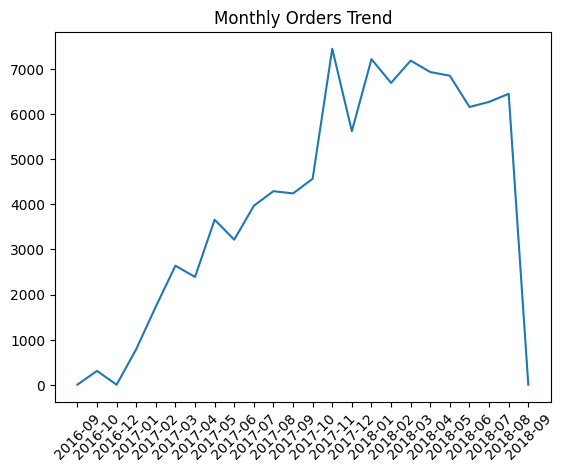

In [17]:
orders_monthly = df.groupby('month')['order_id'].nunique().reset_index()

import matplotlib.pyplot as plt

orders_monthly['month'] = orders_monthly['month'].astype(str)

plt.plot(orders_monthly['month'], orders_monthly['order_id'])
plt.xticks(rotation=45)
plt.title("Monthly Orders Trend")
plt.show()